# Введение
## Цель
Изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard. 
## Задачи
1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:
    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);
    - Деревья решений (Decision Tree);
    - Линейный дискриминантный анализ (Linear Discriminant Analysis);
    - Метод опорных векторов (Support Vector Machines);
    - Метод ближайших соседей (k-Nearest Neighbors);
2. Затем сравните качество работы классификаторов с помощью следующих метрик:
    - Accuracy (точность),
    - Precision (доля правильно классифицированных положительных примеров),
    - Recall (чувствительность, доля верно найденных положительных примеров),
    - F1-Score (среднее гармоническое precision и recall),
    - Площадь под кривой ROC (AUC-ROC).
3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.
4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

# Выбор и подготовка датасета
## Описание датасета
Для работы выбран датасет [Wine Quality Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset). 

Этот датасет содержит информацию о красных винах португальского региона "Винью Верде". Данные были собраны в результате физико-химических лабораторных тестов, а целевая переменная (качество) основана на сенсорной оценке (дегустации).
Признаки:
1. fixed acidity - титруемая кислотность
2. volatile acidity - летучая кислотность
3. citric acid - лимонная кислота
4. residual sugar - остаточный сахар
5. chlorides - хлориды
6. free sulfur dioxide - свободный диоксид серы
7. total sulfur dioxide - общий диоксид серы
8. density - плотность
9. pH - водородный показатель
10. sulphates - сульфаты
11. alcohol - алкоголь (в %)
12. quality - качество (от 0 до 10)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from mlxtend.preprocessing import TransactionEncoder
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import math
import scipy.stats as stats

file_path = "WineQT.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
)

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

## Анализ параметров

In [22]:
# Функция для построения гистограммы распределения признаков и вывода стастистики
def print_stats(dataframe, feature_name, k):
    plt.hist(dataframe[feature_name], bins=k, edgecolor='black')
    plt.title(f'Распределение признака {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Частота')

    shapiro_test = stats.shapiro(dataframe[feature_name])
    dagostino_test = stats.normaltest(dataframe[feature_name])
    ks_test = stats.kstest(
        dataframe[feature_name],
        'norm',
        args=(dataframe[feature_name].mean(), dataframe[feature_name].std())
    )

    def interpret_pvalue(p):
        if p > 0.05:
            return "Нормальное"
        elif p > 0.01:
            return "Близко к нормальному"
        else:
            return "Далеко от нормального"

    # Дескриптивный анализ
    print (
        f"Статистика для признака {feature_name}:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Среднее:                  | {dataframe[feature_name].mean()}\n"
        f"Медиана:                  | {dataframe[feature_name].median()}\n"
        f"Мода:                     | {dataframe[feature_name].mode()[0]}\n"
        f"Минимум:                  | {dataframe[feature_name].min()}\n"
        f"Максимум:                 | {dataframe[feature_name].max()}\n"
        f"Размах:                   | {dataframe[feature_name].max() - dataframe[feature_name].min()}\n"
        f"Стандартное отклонение:   | {dataframe[feature_name].std()}\n"
        f"Дисперсия:                | {dataframe[feature_name].var()}\n"
        f"Асимметрия:               | {dataframe[feature_name].skew()}\n"
        f"Эксцесс:                  | {dataframe[feature_name].kurtosis()}\n"
        f"Квантили (25%, 50%, 75%): | {dataframe[feature_name].quantile([0.25, 0.5, 0.75]).to_dict()}\n"
        f"Оценка нормальности распредления:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Шапиро-Уилк:              | p={shapiro_test.pvalue:.3e} → {interpret_pvalue(shapiro_test.pvalue)}\n"
        f"Д'Агостино-Пиросона:      | p={dagostino_test.pvalue:.3e} → {interpret_pvalue(dagostino_test.pvalue)}\n"
        f"Колмагорова-Смирнова      | p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}\n"
    )

n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

### 1. fixed acidity - титруемая кислотность

Статистика для признака fixed acidity:
--------------------------|-------------------------------------------
Среднее:                  | 8.311111111111112
Медиана:                  | 7.9
Мода:                     | 7.2
Минимум:                  | 4.6
Максимум:                 | 15.9
Размах:                   | 11.3
Стандартное отклонение:   | 1.74759501716954
Дисперсия:                | 3.054088344035805
Асимметрия:               | 1.0449299563724053
Эксцесс:                  | 1.3846135487241824
Квантили (25%, 50%, 75%): | {0.25: 7.1, 0.5: 7.9, 0.75: 9.1}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.239e-21 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.076e-40 → Далеко от нормального
Колмагорова-Смирнова      | p=4.679e-12 → Далеко от нормального



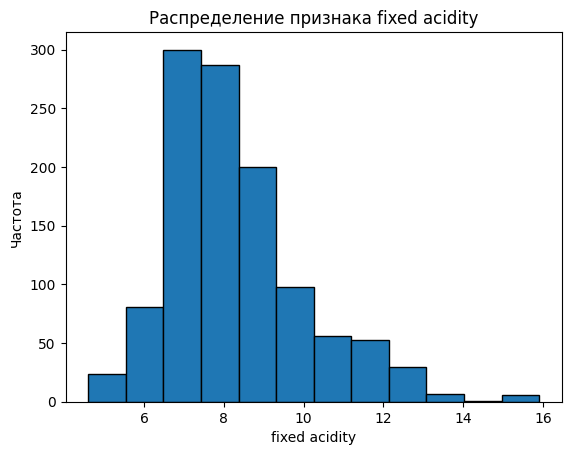

In [23]:
print_stats(df, "fixed acidity", k)

### 2. volatile acidity - летучая кислотность

Статистика для признака volatile acidity:
--------------------------|-------------------------------------------
Среднее:                  | 0.5313385826771653
Медиана:                  | 0.52
Мода:                     | 0.5
Минимум:                  | 0.12
Максимум:                 | 1.58
Размах:                   | 1.46
Стандартное отклонение:   | 0.1796331930225245
Дисперсия:                | 0.03226808403546755
Асимметрия:               | 0.6815474143781255
Эксцесс:                  | 1.3755312990014108
Квантили (25%, 50%, 75%): | {0.25: 0.3925, 0.5: 0.52, 0.75: 0.64}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.129e-13 → Далеко от нормального
Д'Агостино-Пиросона:      | p=1.258e-24 → Далеко от нормального
Колмагорова-Смирнова      | p=5.665e-03 → Далеко от нормального



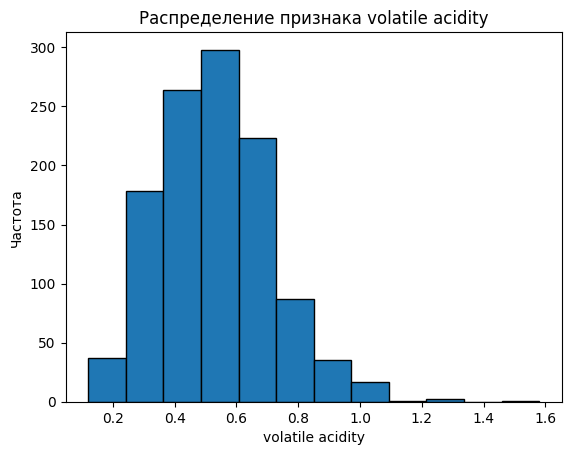

In [24]:
print_stats(df, "volatile acidity", k)

### 3. citric acid - лимонная кислота

Статистика для признака citric acid:
--------------------------|-------------------------------------------
Среднее:                  | 0.2683639545056868
Медиана:                  | 0.25
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 1.0
Размах:                   | 1.0
Стандартное отклонение:   | 0.19668585234821898
Дисперсия:                | 0.03868532451394539
Асимметрия:               | 0.3715607833706083
Эксцесс:                  | -0.714685604436653
Квантили (25%, 50%, 75%): | {0.25: 0.09, 0.5: 0.25, 0.75: 0.42}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.274e-18 → Далеко от нормального
Д'Агостино-Пиросона:      | p=7.895e-20 → Далеко от нормального
Колмагорова-Смирнова      | p=7.683e-08 → Далеко от нормального



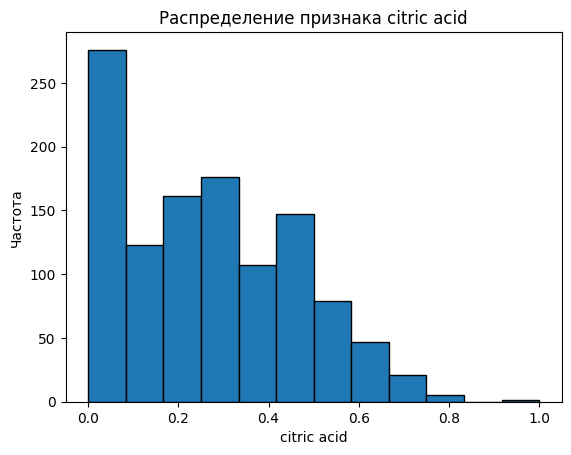

In [25]:
print_stats(df, "citric acid", k)

### 4. residual sugar - остаточный сахар

Статистика для признака residual sugar:
--------------------------|-------------------------------------------
Среднее:                  | 2.5321522309711284
Медиана:                  | 2.2
Мода:                     | 2.0
Минимум:                  | 0.9
Максимум:                 | 15.5
Размах:                   | 14.6
Стандартное отклонение:   | 1.3559174666826799
Дисперсия:                | 1.8385121764551762
Асимметрия:               | 4.361096404323471
Эксцесс:                  | 27.675365893093414
Квантили (25%, 50%, 75%): | {0.25: 1.9, 0.5: 2.2, 0.75: 2.6}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=9.188e-46 → Далеко от нормального
Д'Агостино-Пиросона:      | p=8.233e-233 → Далеко от нормального
Колмагорова-Смирнова      | p=5.887e-68 → Далеко от нормального



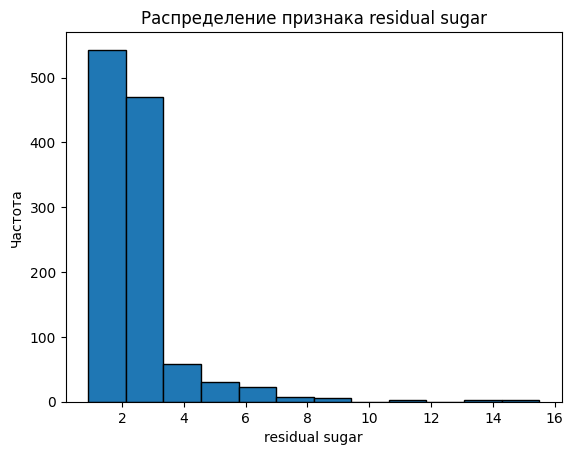

In [26]:
print_stats(df, "residual sugar", k)

### 5. chlorides - хлориды

Статистика для признака chlorides:
--------------------------|-------------------------------------------
Среднее:                  | 0.08693263342082239
Медиана:                  | 0.079
Мода:                     | 0.08
Минимум:                  | 0.012
Максимум:                 | 0.611
Размах:                   | 0.599
Стандартное отклонение:   | 0.04726733795238057
Дисперсия:                | 0.0022342012371045564
Асимметрия:               | 6.026360154399587
Эксцесс:                  | 47.07832426734653
Квантили (25%, 50%, 75%): | {0.25: 0.07, 0.5: 0.079, 0.75: 0.09}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.025e-49 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.137e-292 → Далеко от нормального
Колмагорова-Смирнова      | p=1.097e-67 → Далеко от нормального



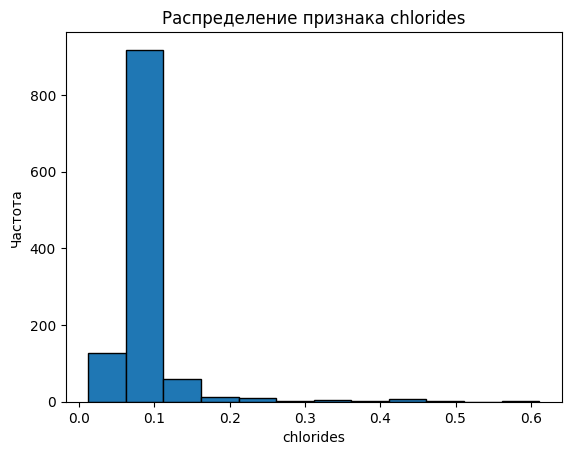

In [27]:
print_stats(df, "chlorides", k)

### 6. free sulfur dioxide - свободный диоксид серы

Статистика для признака free sulfur dioxide:
--------------------------|-------------------------------------------
Среднее:                  | 15.615485564304462
Медиана:                  | 13.0
Мода:                     | 6.0
Минимум:                  | 1.0
Максимум:                 | 68.0
Размах:                   | 67.0
Стандартное отклонение:   | 10.250486123430822
Дисперсия:                | 105.07246576664782
Асимметрия:               | 1.2312611567075427
Эксцесс:                  | 1.9321699270318087
Квантили (25%, 50%, 75%): | {0.25: 7.0, 0.5: 13.0, 0.75: 21.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.200e-26 → Далеко от нормального
Д'Агостино-Пиросона:      | p=9.724e-53 → Далеко от нормального
Колмагорова-Смирнова      | p=1.948e-12 → Далеко от нормального



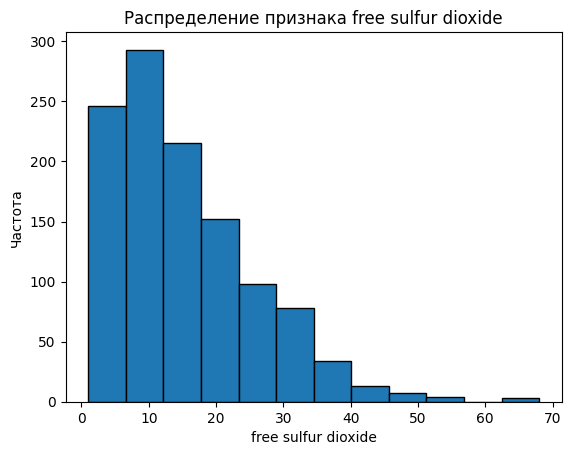

In [28]:
print_stats(df, "free sulfur dioxide", k)

### 7. total sulfur dioxide - общий диоксид серы

Статистика для признака total sulfur dioxide:
--------------------------|-------------------------------------------
Среднее:                  | 45.91469816272966
Медиана:                  | 37.0
Мода:                     | 28.0
Минимум:                  | 6.0
Максимум:                 | 289.0
Размах:                   | 283.0
Стандартное отклонение:   | 32.78213030734311
Дисперсия:                | 1074.6680674876238
Асимметрия:               | 1.6657660141342994
Эксцесс:                  | 5.098747772114013
Квантили (25%, 50%, 75%): | {0.25: 21.0, 0.5: 37.0, 0.75: 61.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.074e-30 → Далеко от нормального
Д'Агостино-Пиросона:      | p=5.798e-90 → Далеко от нормального
Колмагорова-Смирнова      | p=4.584e-15 → Далеко от нормального



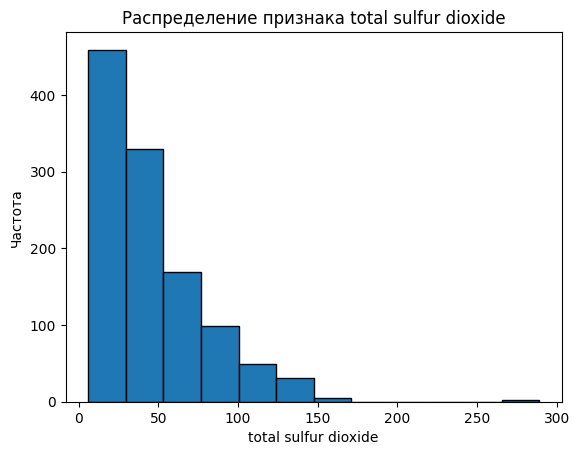

In [29]:
print_stats(df, "total sulfur dioxide", k)

### 8. density - плотность

Статистика для признака density:
--------------------------|-------------------------------------------
Среднее:                  | 0.9967304111986001
Медиана:                  | 0.99668
Мода:                     | 0.9976
Минимум:                  | 0.99007
Максимум:                 | 1.00369
Размах:                   | 0.013619999999999965
Стандартное отклонение:   | 0.0019250671302545696
Дисперсия:                | 3.705883455986564e-06
Асимметрия:               | 0.102395108720599
Эксцесс:                  | 0.8881232998796076
Квантили (25%, 50%, 75%): | {0.25: 0.99557, 0.5: 0.99668, 0.75: 0.997845}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.246e-06 → Далеко от нормального
Д'Агостино-Пиросона:      | p=1.772e-05 → Далеко от нормального
Колмагорова-Смирнова      | p=2.312e-02 → Близко к нормальному



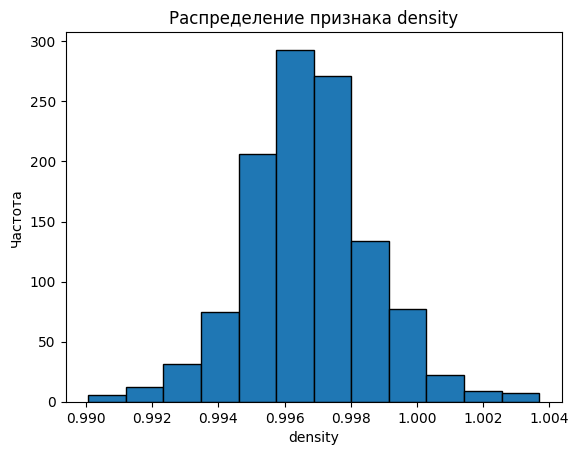

In [30]:
print_stats(df, "density", k)

### 9. pH - водородный показатель

Статистика для признака pH:
--------------------------|-------------------------------------------
Среднее:                  | 3.3110148731408575
Медиана:                  | 3.31
Мода:                     | 3.3
Минимум:                  | 2.74
Максимум:                 | 4.01
Размах:                   | 1.2699999999999996
Стандартное отклонение:   | 0.15666405977275194
Дисперсия:                | 0.02454362762448039
Асимметрия:               | 0.22113839209685748
Эксцесс:                  | 0.9257908123096237
Квантили (25%, 50%, 75%): | {0.25: 3.205, 0.5: 3.31, 0.75: 3.4}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=8.673e-06 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.670e-07 → Далеко от нормального
Колмагорова-Смирнова      | p=1.425e-02 → Близко к нормальному



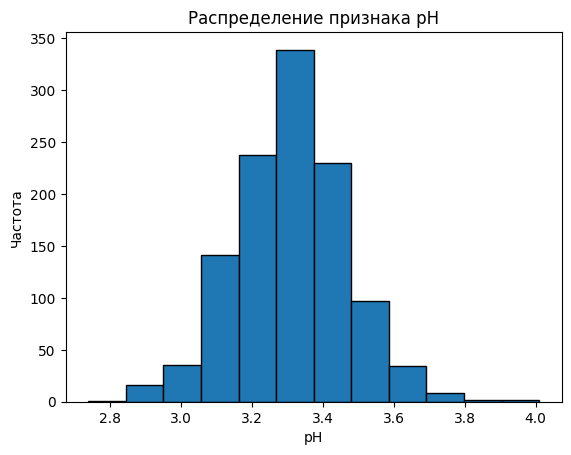

In [31]:
print_stats(df, "pH", k)

### 10. sulphates - сульфаты

Статистика для признака sulphates:
--------------------------|-------------------------------------------
Среднее:                  | 0.6577077865266842
Медиана:                  | 0.62
Мода:                     | 0.6
Минимум:                  | 0.33
Максимум:                 | 2.0
Размах:                   | 1.67
Стандартное отклонение:   | 0.1703987144670741
Дисперсия:                | 0.029035721892031453
Асимметрия:               | 2.497266051332364
Эксцесс:                  | 12.017377028997274
Квантили (25%, 50%, 75%): | {0.25: 0.55, 0.5: 0.62, 0.75: 0.73}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.265e-33 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.955e-146 → Далеко от нормального
Колмагорова-Смирнова      | p=2.989e-17 → Далеко от нормального



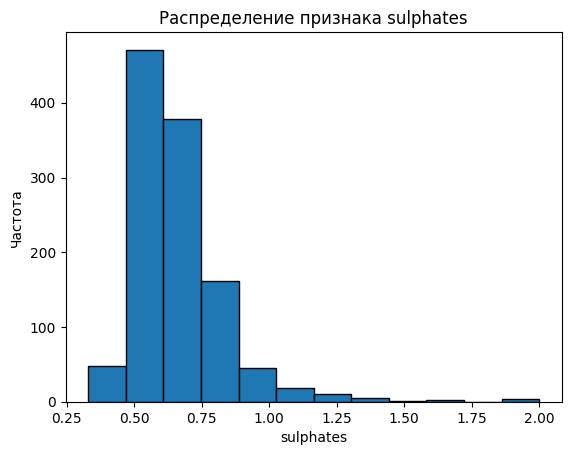

In [32]:
print_stats(df, "sulphates", k)

### 11. alcohol - алкоголь (в %)

Статистика для признака alcohol:
--------------------------|-------------------------------------------
Среднее:                  | 10.442111402741325
Медиана:                  | 10.2
Мода:                     | 9.5
Минимум:                  | 8.4
Максимум:                 | 14.9
Размах:                   | 6.5
Стандартное отклонение:   | 1.0821956098764445
Дисперсия:                | 1.1711473380358497
Асимметрия:               | 0.8633132317223615
Эксцесс:                  | 0.22117896845525786
Квантили (25%, 50%, 75%): | {0.25: 9.5, 0.5: 10.2, 0.75: 11.1}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=7.517e-23 → Далеко от нормального
Д'Агостино-Пиросона:      | p=5.936e-25 → Далеко от нормального
Колмагорова-Смирнова      | p=3.256e-16 → Далеко от нормального



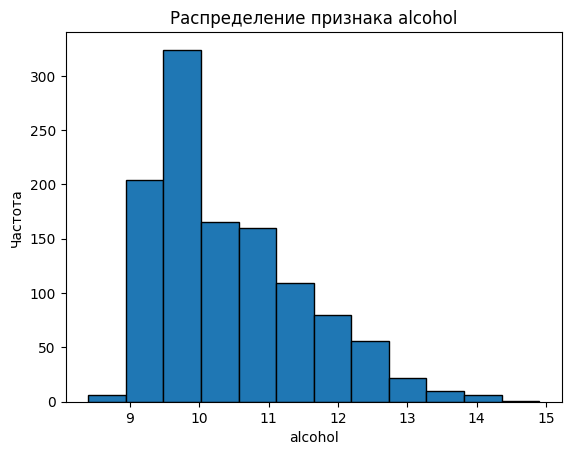

In [33]:
print_stats(df, "alcohol", k)

### 12. quality - качество (от 0 до 10)

Статистика для признака quality:
--------------------------|-------------------------------------------
Среднее:                  | 5.657042869641295
Медиана:                  | 6.0
Мода:                     | 5
Минимум:                  | 3
Максимум:                 | 8
Размах:                   | 5
Стандартное отклонение:   | 0.8058242481000952
Дисперсия:                | 0.6493527188260838
Асимметрия:               | 0.2867917004538591
Эксцесс:                  | 0.3146639385893346
Квантили (25%, 50%, 75%): | {0.25: 5.0, 0.5: 6.0, 0.75: 6.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=3.607e-31 → Далеко от нормального
Д'Агостино-Пиросона:      | p=6.990e-05 → Далеко от нормального
Колмагорова-Смирнова      | p=4.729e-63 → Далеко от нормального



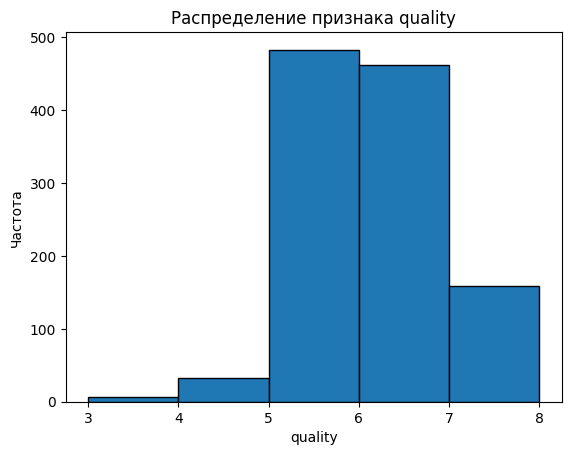

In [36]:
print_stats(df, "quality", 5)

# Разбиение выборки

In [ ]:
seed = 666
